In [1]:
# download image matting dataset
import kagglehub
path = kagglehub.dataset_download("kocabiyik/withoutbg100-image-matting-dataset")
print("Path to dataset files:", path)

100%|██████████| 15.3M/15.3M [00:00<00:00, 118MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kocabiyik/withoutbg100-image-matting-dataset/versions/1


In [2]:
!ls -l $path/img

total 6528
-rw-r--r-- 1 root root  49015 Mar 27 21:00 alexander-startsev-fkNXavW6mYQ-unsplash.jpg
-rw-r--r-- 1 root root  63628 Mar 27 21:00 alexander-startsev-KBMSA9iq0Yw-unsplash.jpg
-rw-r--r-- 1 root root  83116 Mar 27 21:00 alex-batonisashvili-ftVWtw-l4TY-unsplash.jpg
-rw-r--r-- 1 root root  46818 Mar 27 21:00 alina-and-david-nTuOy4ekklc-unsplash.jpg
-rw-r--r-- 1 root root 134845 Mar 27 21:00 aliona-gumeniuk-AOQ83RPea60-unsplash.jpg
-rw-r--r-- 1 root root  39555 Mar 27 21:00 ananthu-selvam-62saZ_T5AP0-unsplash.jpg
-rw-r--r-- 1 root root 109336 Mar 27 21:00 andy-wrights-Uc-tVq5SCnE-unsplash.jpg
-rw-r--r-- 1 root root  62881 Mar 27 21:00 annie-spratt-fiMx7fLi5F8-unsplash.jpg
-rw-r--r-- 1 root root  55349 Mar 27 21:00 annie-spratt-hfIqGRZMdkA-unsplash.jpg
-rw-r--r-- 1 root root  69780 Mar 27 21:00 antoinette-biehlmeier-BfM7jFmAyuI-unsplash.jpg
-rw-r--r-- 1 root root  72034 Mar 27 21:00 an_vision-3914AqKv8Kc-unsplash.jpg
-rw-r--r-- 1 root root  26541 Mar 27 21:00 aral-tasher-fkCBrzqy-U

In [3]:
imgpath = path+"/img/claudio-guglieri-K2RH1QZdLF4-unsplash.jpg"

In [4]:
!pip install fastncut

In [5]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import torch
from fastncut import ncut, toCosSin, extendWithPositionEncoding, extendWithFix

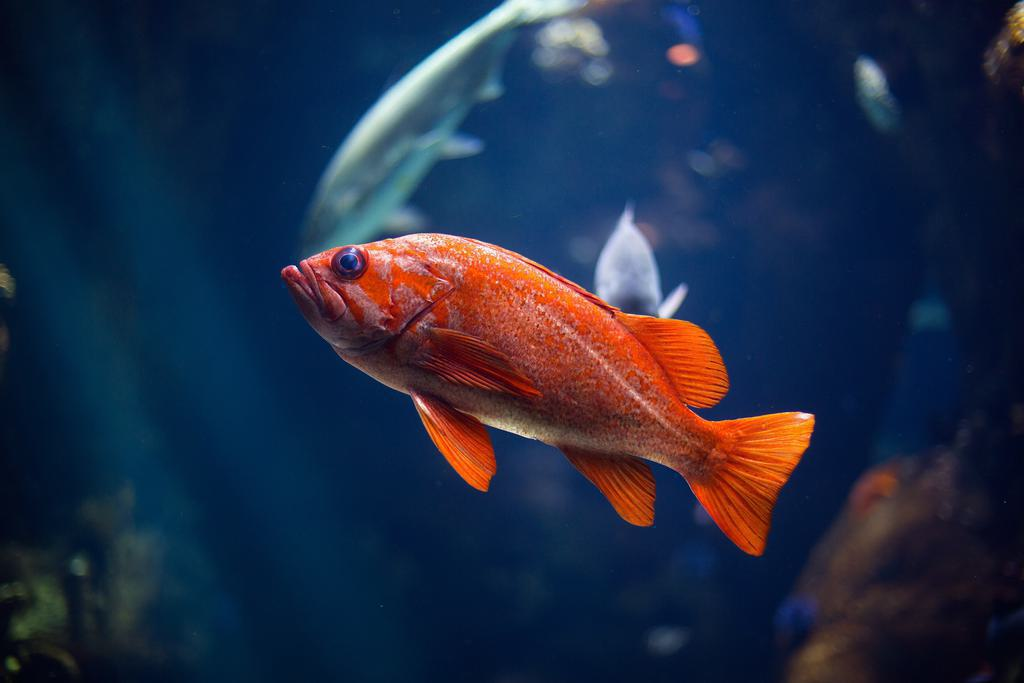

In [6]:
img = cv2.imread(imgpath)
cv2_imshow(img)

In [7]:
hue = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,0]

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


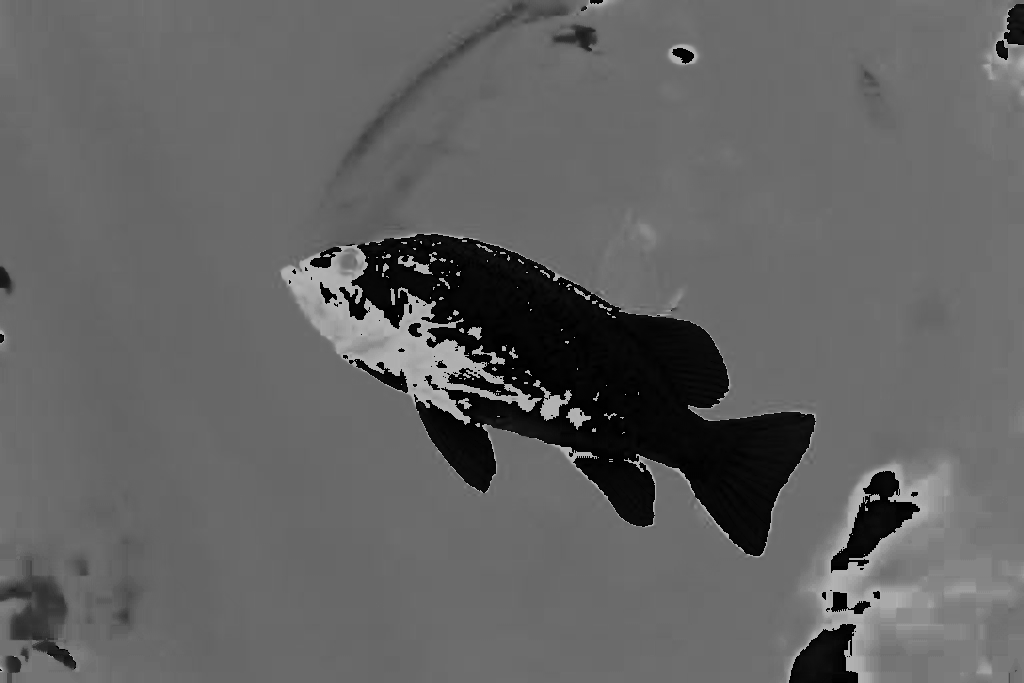

In [9]:
cv2_imshow(hue)

In [10]:
hue.shape

(683, 1024)

In [11]:
blob = extendWithFix(toCosSin(torch.Tensor(hue,device=device).unsqueeze(0).float()/180.0,wrap_around=True))

In [12]:
blob.shape

torch.Size([3, 683, 1024])

In [13]:
bipartition0 = ncut(blob, num_iters=1)

In [14]:
print(bipartition0.shape, bipartition0.dtype)

torch.Size([683, 1024]) torch.bool


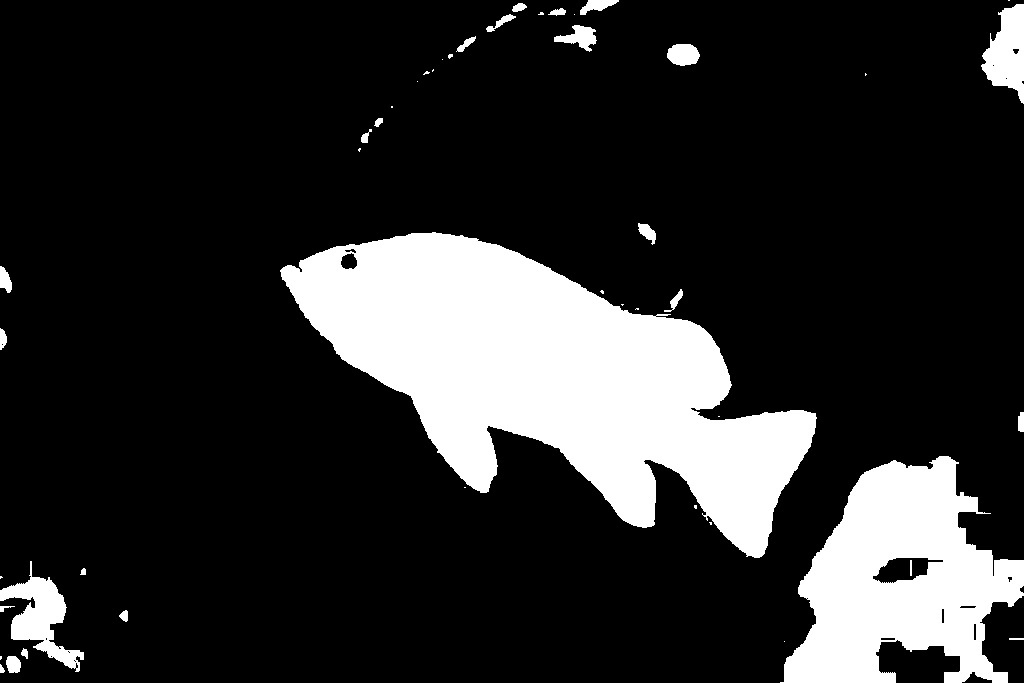

In [15]:
cv2_imshow(bipartition0.cpu().numpy()*255)